In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Mount into drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# Change directory to the package folder
%cd '/content/drive/MyDrive/hateful_meme'
# Verify the contents of the current folder
!ls

/content/drive/MyDrive/hateful_meme
data					 mmf
Hateful_Meme_mmbt.ipynb			 mmf_hm_example.ipynb
Hateful_Meme_MMBT.ipynb			 old_save
Hateful_Memes_Custom_Model.ipynb	 report
Hateful_Memes_mmbt_Analysis.ipynb	 requirements.txt
Hateful_Memes_VilBert_Analysis.ipynb	 roc.png
HATEFUL_MEMES_VIlbert_visualBert	 save_mmbt
Hateful_Memes_VisualBert_Analysis.ipynb  save_vilbert
hateful_memes.zip			 save_visual_bert
Hateful_Meme_VisualBert.ipynb


In [11]:
# validation
df = pd.read_csv("report/test_mmbt.csv")
df.columns = ['id', 'proba', 'predicted_label']

In [12]:
#validation
#Import the correct answers
import json
labels = []
file = open("data/dev_seen.jsonl", "r")
for line in file.readlines():
  dic = json.loads(line)
  labels.append(dic)
file = open("data/dev_unseen.jsonl", "r")
for line in file.readlines():
  dic = json.loads(line)
  labels.append(dic)

In [ ]:
df_final

In [13]:
df_truth = pd.DataFrame(labels)
df_final = pd.merge(df, df_truth, how='left', on='id')
def getType(row):
  if row['predicted_label'] == row['label'] and row['label'] == 1:
    return "TP"
  elif row['predicted_label'] == row['label'] and row['label'] == 0:
    return "TN"
  elif row['predicted_label'] == 1 and row['label'] == 0:
    return "FP"
  elif row['predicted_label'] == 0 and row['label'] == 1:
    return "FN"
df_final['type'] = df_final.apply(lambda row: getType(row), axis=1)
df_final = df_final.drop_duplicates()
df_final.head()

,id,proba,predicted_label,img,label,text,type
0,8291,0.000004,0,img/08291.png,1,white people is this a shooting range,FN
2,46971,0.000004,0,img/46971.png,1,bravery at its finest,FN
4,3745,0.000003,0,img/03745.png,1,your order comes to $37.50 and your white priv...,FN
6,83745,0.000003,0,img/83745.png,1,it is time.. to send these parasites back to t...,FN
8,80243,0.002062,0,img/80243.png,1,mississippi wind chime,FN


              precision    recall  f1-score   support

 Non-Hateful       0.57      0.86      0.69       253
     Hateful       0.70      0.35      0.47       247

    accuracy                           0.61       500
   macro avg       0.64      0.60      0.58       500
weighted avg       0.64      0.61      0.58       500



Text(0.5, 1.0, 'Confusion Matrix for Visual-BERT')

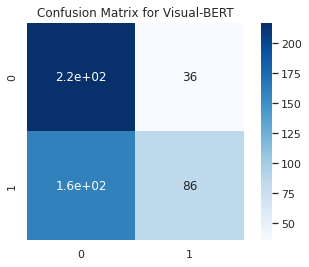

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, precision_recall_curve, plot_precision_recall_curve, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

print(classification_report(df_final['label'], df_final['predicted_label'], target_names=['Non-Hateful', 'Hateful']))
conf = confusion_matrix(df_final['label'], df_final['predicted_label'])
sns.heatmap(conf, annot=True, square=True, cmap="Blues")
plt.title("Confusion Matrix for Visual-BERT")

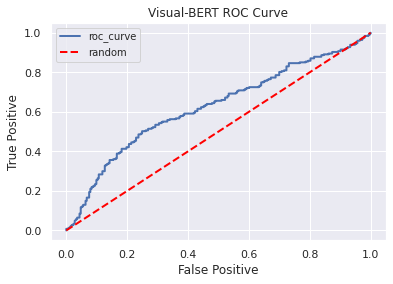

ROC AUC:  0.6250020002880415


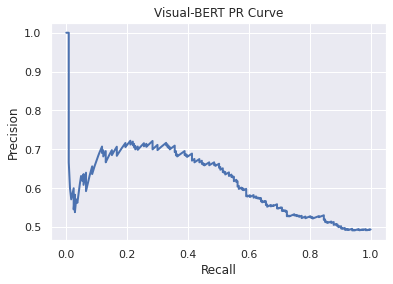

In [15]:
fpr, tpr, thresholds1 = roc_curve(df_final['label'], df_final['proba'])
plt.figure(1)
plt.title("Visual-BERT ROC Curve")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.plot(fpr,tpr, linewidth=2, label="roc_curve")
plt.plot([0,1],[0,1], linestyle="dashed", color="red", linewidth=2, label="random")
plt.legend(fontsize=10, loc="best")
plt.savefig('roc.png')
plt.show()

roc_auc = np.trapz(tpr, fpr)
print("ROC AUC: ", roc_auc)
#Plot PR Curve
plt.figure(2)
plt.title("Visual-BERT PR Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
precision, recall, thresholds2 = precision_recall_curve(df_final['label'], df_final['proba'])
plt.plot(recall, precision, linewidth=2)
plt.show()

In [16]:
df_final.groupby("type")['id'].count()

type
FN    161
FP     36
TN    217
TP     86
Name: id, dtype: int64

In [17]:
top_tp = df_final[df_final['type']=='TP'].sort_values('proba', ascending=False).head()
top_tn = df_final[df_final['type']=='TN'].sort_values('proba', ascending=True).head()
top_fp = df_final[df_final['type']=='FP'].sort_values('proba', ascending=False).head(10)
top_fn = df_final[df_final['type']=='FN'].sort_values('proba', ascending=True).head(10)

In [18]:
!pip install git+https://github.com/facebookresearch/mmf.git

  Cloning https://github.com/facebookresearch/mmf.git to /tmp/pip-req-build-y03u45z_
  Running command git clone -q https://github.com/facebookresearch/mmf.git /tmp/pip-req-build-y03u45z_
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
  Cloning https://github.com/PyTorchLightning/pytorch-lightning (to revision fa0ed17f8) to /tmp/pip-install-nqzceib6/pytorch-lightning_d1a42411f63a49329e6e86f48b23b7a1
  Running command git clone -q https://github.com/PyTorchLightning/pytorch-lightning /tmp/pip-install-nqzceib6/pytorch-lightning_d1a42411f63a49329e6e86f48b23b7a1
  Running command git checkout -q fa0ed17f8
  Running command git submodule update --init --recursive -q
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
     |████████████████████████████████| 1.5 MB 6.9 MB/s 
     |████████████████████████████████| 831.4 MB 2.7 kB/s 
     |███

In [19]:
!pip install --upgrade --pre mmf

     |████████████████████████████████| 404 kB 8.6 MB/s 
     |████████████████████████████████| 447 kB 50.1 MB/s 
     |████████████████████████████████| 6.6 MB 18.7 MB/s 
  Using cached nltk-3.4.5-py3-none-any.whl
  Using cached torchtext-0.5.0-py3-none-any.whl (73 kB)
  Using cached GitPython-3.1.0-py3-none-any.whl (450 kB)
  Using cached fasttext-0.9.1-cp37-cp37m-linux_x86_64.whl
     |████████████████████████████████| 131 kB 63.6 MB/s 
  Using cached lmdb-0.98-cp37-cp37m-linux_x86_64.whl
     |████████████████████████████████| 752.0 MB 10.0 kB/s 
  Using cached gitdb-4.0.9-py3-none-any.whl (63 kB)
  Using cached PyYAML-6.0-cp37-cp37m-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_12_x86_64.manylinux2010_x86_64.whl (596 kB)
  Using cached sentencepiece-0.1.96-cp37-cp37m-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.2 MB)
     |████████████████████████████████| 131 kB 55.5 MB/s 
  Using cached sacremoses-0.0.46-py3-none-any.whl (895 kB)
  Using cached smmap-5.0.0-py3-none-an

In [20]:
!mmf_convert_hm --zip_file='/content/drive/My Drive/hateful_meme/hateful_memes.zip' --password='' --bypass_checksum=1

/usr/local/lib/python3.7/dist-packages/mmf/utils/configuration.py:527: UserWarning: Device specified is 'cuda' but cuda is not present. Switching to CPU version.
  "Device specified is 'cuda' but cuda is not present. "
Data folder is /root/.cache/torch/mmf/data
Zip path is /content/drive/My Drive/hateful_meme/hateful_memes.zip
Moving /content/drive/My Drive/hateful_meme/hateful_memes.zip
Unzipping /content/drive/My Drive/hateful_meme/hateful_memes.zip
Extracting the zip can take time. Sit back and relax.
Moving train.jsonl
Moving dev.jsonl
Moving test.jsonl
Moving img


In [21]:
top_fp

,id,proba,predicted_label,img,label,text,type
624,8451,0.999996,1,img/08451.png,0,when you ask a jewish girl for her number and ...,FP
788,84150,0.999995,1,img/84150.png,0,when your jewish friend smells a stash of coin...,FP
113,91405,0.999995,1,img/91405.png,0,wears rag on her head so her brother husband d...,FP
365,32579,0.999995,1,img/32579.png,0,come to the dark side we have weed,FP
702,32049,0.999995,1,img/32049.png,0,german british danish austrian diversity. appa...,FP
704,95173,0.999994,1,img/95173.png,0,take the third reich and then the first left?,FP
538,43092,0.999994,1,img/43092.png,0,pretty much sums up islam,FP
433,91468,0.999993,1,img/91468.png,0,you want a whore? buy one. you want a queen? e...,FP
434,52104,0.999993,1,img/52104.png,0,lebanon: before islam after islam but don't wo...,FP
289,41058,0.999993,1,img/41058.png,0,john wilkes booth be like: yall sure abraham l...,FP


In [22]:
import cv2
def plot_top_memes(df_top, incorrect=False):
  root = '/root/.cache/torch/mmf/data/datasets/hateful_memes/defaults/images/'
  if incorrect:
    fig, ax = plt.subplots(2, 5, figsize=(35, 20))
  else:
    fig, ax = plt.subplots(1, 5, figsize=(35, 10))
  imgs = df_top['img'].values
  for i, img in enumerate(imgs):
    im_arr = cv2.imread(root + img)
    im_arr = cv2.cvtColor(im_arr, cv2.COLOR_BGR2RGB)
    if incorrect:
      ax[i//5, i%5].imshow(im_arr)
      ax[i//5, i%5].grid(False)
      ax[i//5, i%5].set_yticklabels([])
      ax[i//5, i%5].set_xticklabels([])
    else:
      ax[i].imshow(im_arr)
      ax[i].grid(False)
      ax[i].set_yticklabels([])
      ax[i].set_xticklabels([])

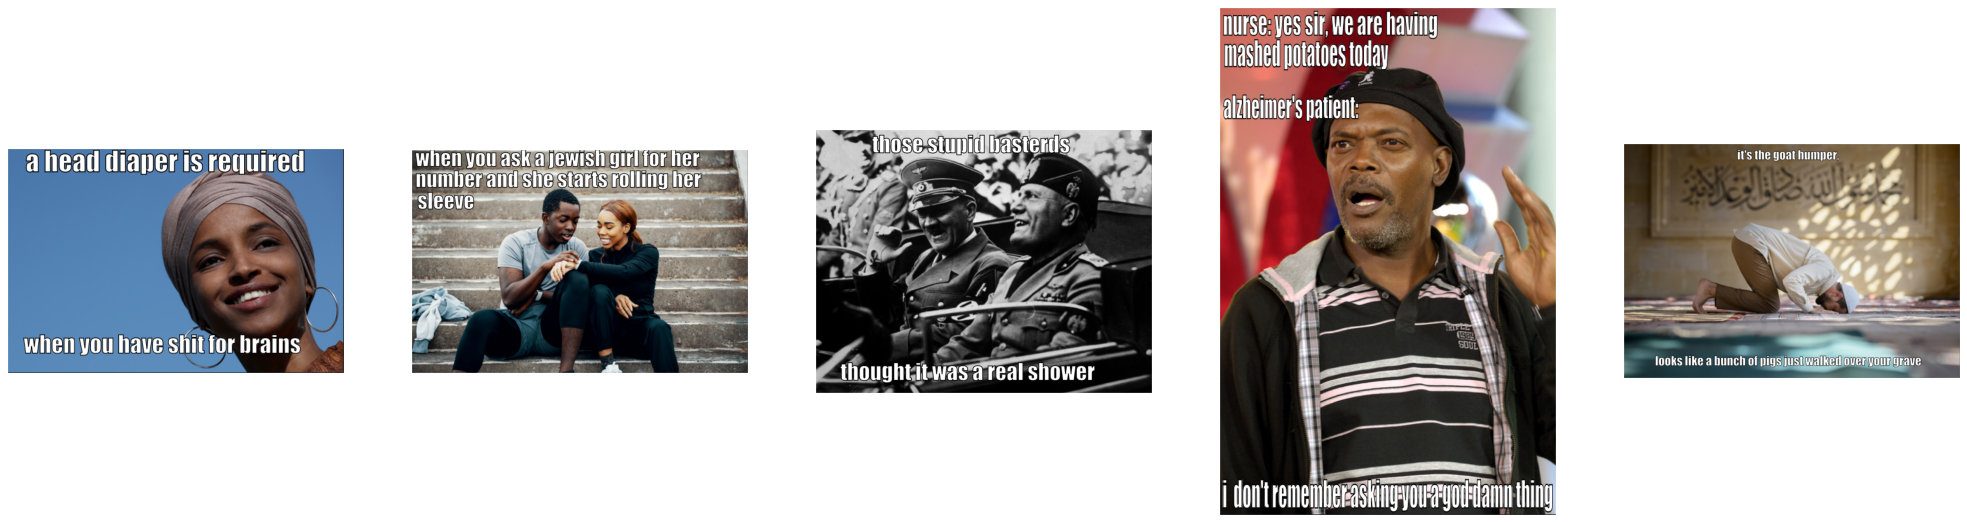

In [23]:
plot_top_memes(top_tp)